<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

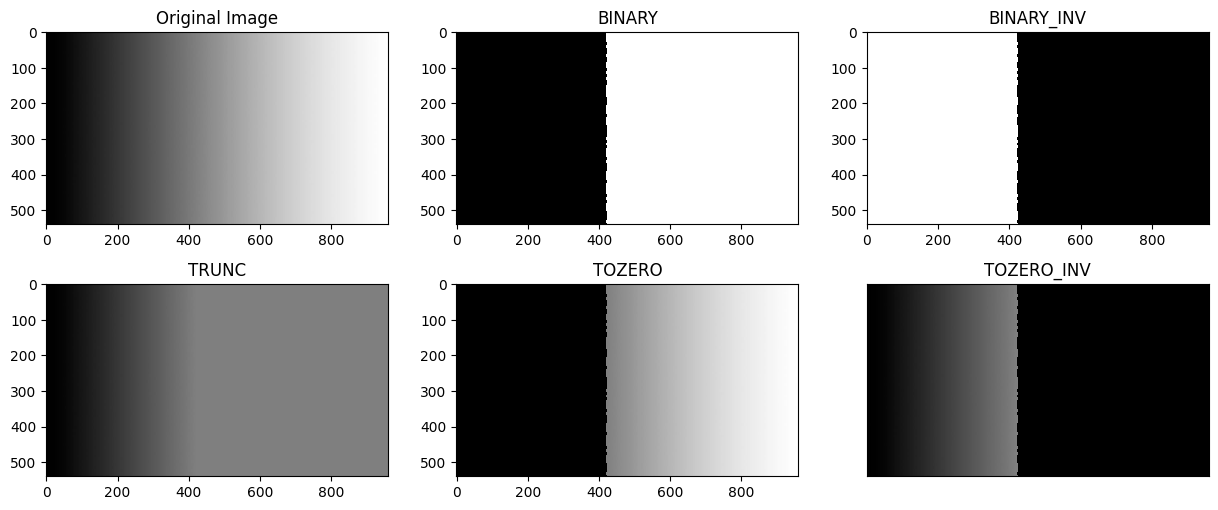

In [ ]:
filename = ('/content/drive/MyDrive/PCVK/gradient.jpg')
img = cv.imread(filename)

thresh = 127
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,6))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])

plt.xticks([]),plt.yticks([])
plt.show()

Optimal Otsu's Threshold (manual): 93


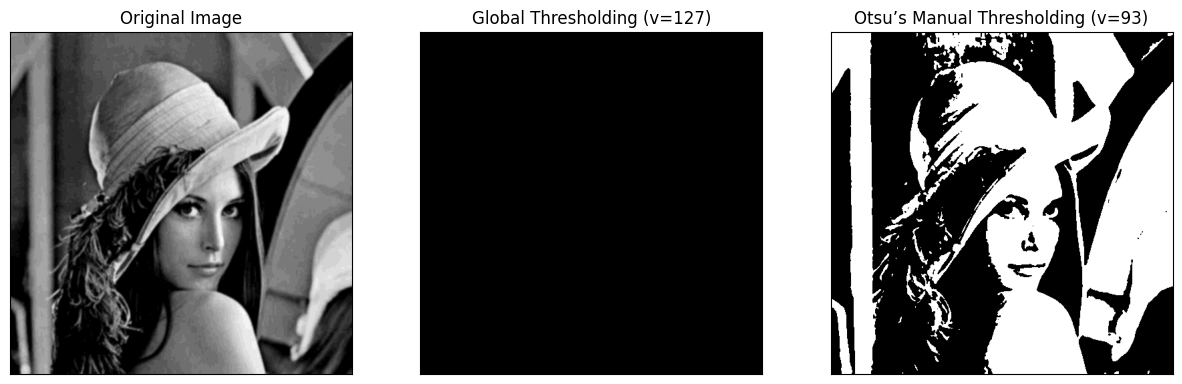

/tmp/ipython-input-3417851444.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_blur.ravel(), 256, [0,256], color='gray')


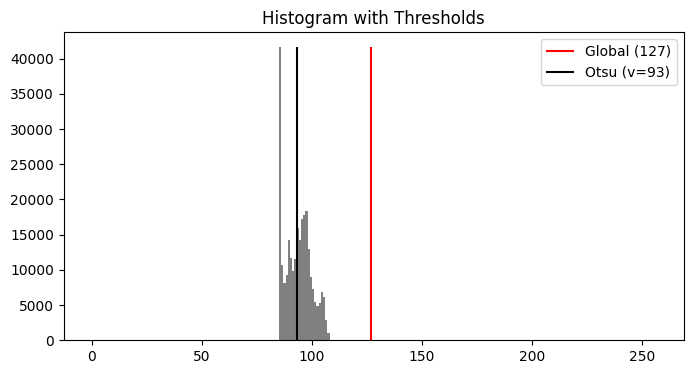

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/lena_gs_lc2.jpg', 0)
img_blur = cv.GaussianBlur(img, (5,5), 0)

hist = cv.calcHist([img_blur],[0],None,[256],[0,256])
histnorm = hist.ravel() / hist.sum()

best_variance = 0
optimal_threshold = 0

for t in range(256):
    wb = np.sum(histnorm[:t])
    wf = np.sum(histnorm[t:])

    if wb == 0 or wf == 0:
        continue

    mean_b = np.sum(np.arange(t) * histnorm[:t]) / wb
    mean_f = np.sum(np.arange(t, 256) * histnorm[t:]) / wf

    between_class_variance = wb * wf * (mean_b - mean_f) ** 2

    if between_class_variance > best_variance:
        best_variance = between_class_variance
        optimal_threshold = t

print(f"Optimal Otsu's Threshold (manual): {optimal_threshold}")

ret_global, img_global_thresh = cv.threshold(img_blur, 127, 255, cv.THRESH_BINARY)
ret_otsu, img_otsu_manual = cv.threshold(img_blur, optimal_threshold, 255, cv.THRESH_BINARY)

titles = [
    'Original Image',
    'Global Thresholding (v=127)',
    f"Otsu’s Manual Thresholding (v={optimal_threshold})"
]
images = [img_blur, img_global_thresh, img_otsu_manual]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

plt.figure(figsize=(8,4))
plt.hist(img_blur.ravel(), 256, [0,256], color='gray')
plt.vlines(127, 0, hist.max(), colors='red', label='Global (127)')
plt.vlines(optimal_threshold, 0, hist.max(), colors='black', label=f"Otsu (v={optimal_threshold})")
plt.legend()
plt.title('Histogram with Thresholds')
plt.show()

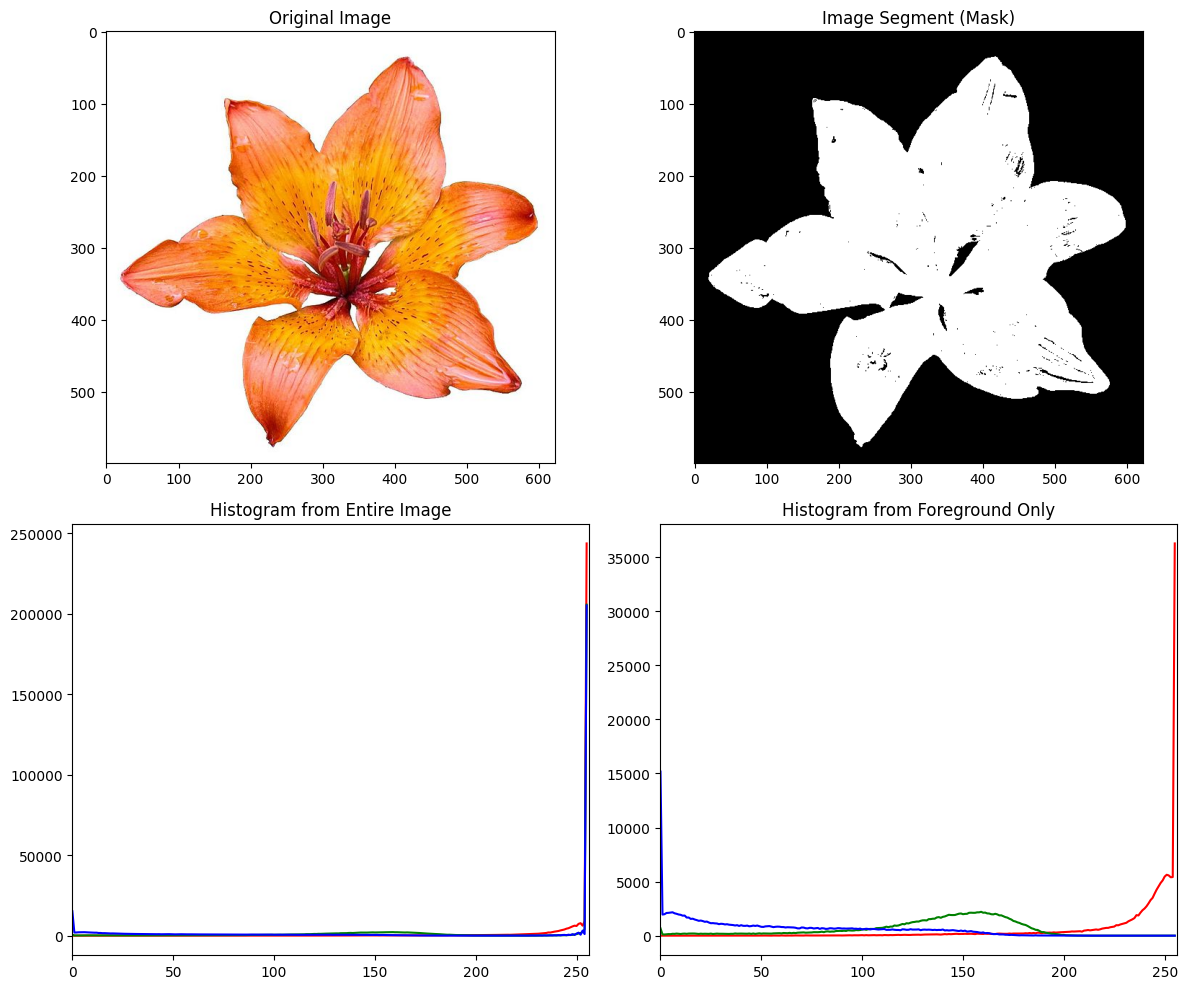

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/lily.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

mean_val = np.mean(gray)
if mean_val > 127:
    threshold_type = cv.THRESH_BINARY_INV + cv.THRESH_OTSU
else:
    threshold_type = cv.THRESH_BINARY + cv.THRESH_OTSU

ret, mask = cv.threshold(gray, 0, 255, threshold_type)

segmented = cv.bitwise_and(img, img, mask=mask)

colors = ('r', 'g', 'b')
hist_full = {}
hist_fg = {}

for i, col in enumerate(colors):
    hist_full[col] = cv.calcHist([img], [i], None, [256], [0, 256])
    hist_fg[col] = cv.calcHist([img], [i], mask, [256], [0, 256])

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title('Original Image')

plt.subplot(2, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Image Segment (Mask)")

plt.subplot(2, 2, 3)
for col in colors:
    plt.plot(hist_full[col], color=col)
plt.title('Histogram from Entire Image')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
for col in colors:
    plt.plot(hist_fg[col], color=col)
plt.title('Histogram from Foreground Only')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

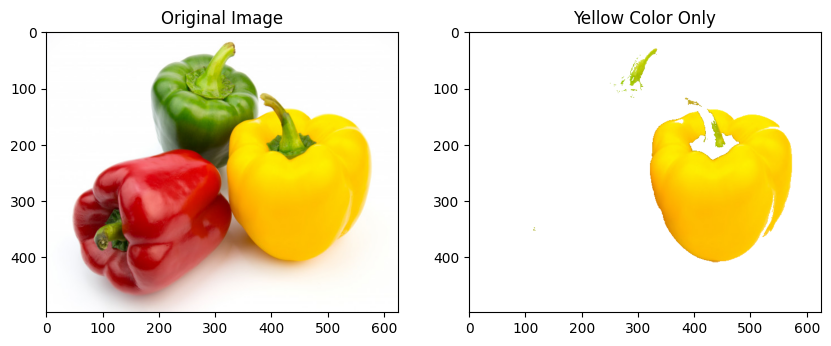

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
imgrgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

pixel_values = imgrgb.reshape((-1, 3)).astype(np.float32)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 6
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 5, cv.KMEANS_PP_CENTERS)

centers = np.uint8(centers)
labels = labels.flatten()

target_color = np.array([255, 255, 0])
cluster_index = np.argmin(np.linalg.norm(centers - target_color, axis=1))

segmented = centers[labels].reshape(imgrgb.shape)
mask = (labels == cluster_index).reshape(imgrgb.shape[:2])

result = imgrgb.copy()
result[~mask] = [255, 255, 255]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imgrgb)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('Yellow Color Only')
plt.show()

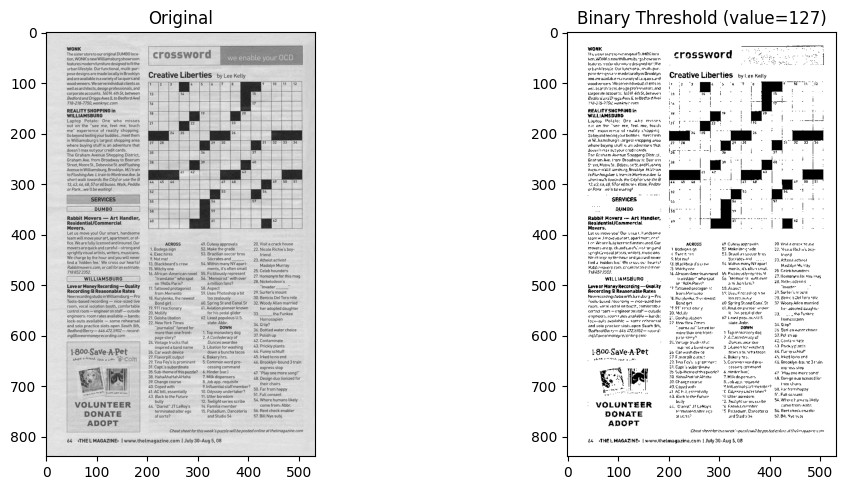

In [ ]:
import cv2

img_path = '/content/drive/MyDrive/PCVK/crossword.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

threshold_value = 127
ret, binary_thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(binary_thresh, cmap='gray')
plt.title(f"Binary Threshold (value={threshold_value})")

plt.tight_layout()
plt.show()